<a href="https://colab.research.google.com/github/sandeepmohamed666/ICTAK_B9_Python-Case-Study/blob/main/Case_Study_on_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) Importing Libraries

In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# 2) Dataset Overview

## a) Loading & Reading Dataset

In [257]:
filepath = '/content/drive/MyDrive/ICTAK-DSA-B9/----Case study + Live Coding----/- x) Data Preprocessing/Data Preprocessing - Case Study/House_Pricing.csv'

In [258]:
customer_df = pd.read_csv(filepath)
customer_df.head(2)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639


## b) Exploring Data

In [152]:
# df.info() - to give a concise summary of your DataFrame

customer_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21613 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21613 non-null  float64
 5   Flat Area (in Sqft)                        21613 non-null  float64
 6   Lot Area (in Sqft)                         21613 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [153]:
# describe() - to give a statistical information from the dataset

customer_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21612.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401817e+05,3.370842,2.114757,2079.861010,1.510464e+04,1.494309,7.623467,1788.312497,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.532133,12768.455652
std,2.876566e+09,3.673570e+05,0.930062,0.770069,918.302876,4.141992e+04,0.539989,1.105439,827.929506,442.575043,29.373411,401.679240,53.505425,0.138562,0.140827,685.389122,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.220000e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# 3) Duplicate Removal

In [154]:
customer_df.head(2)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639


In [155]:
customer_df.shape

(21613, 21)

## a) Checking for  Duplicate Rows

In [156]:
# Checking for  Duplicate Rows

customer_df.duplicated().sum()

np.int64(0)

In [157]:
# No duplicate rows in the dataset

## b) Checking for  Duplicate Columns

In [158]:
duplicate_cols = customer_df.columns[customer_df.T.duplicated()]
# print(duplicate_cols)
duplicate_cols


Index([], dtype='object')

In [159]:
# duplicate_cols = customer_df.T.duplicated()

# print("Duplicate columns based on values:")
# print(customer_df.columns[duplicate_cols])

In [160]:
# No duplicate column names in the dataset.
## Every column name in House_pricing is unique.
## No two columns share the same header string.

In [161]:
customer_df = customer_df.loc[:, ~customer_df.T.duplicated()]

In [162]:
customer_df.shape

(21613, 21)

# 4) Handling Missing Values

## a) Identify missing values in each column.

In [166]:
# Identifying Missing values in Each Column

customer_df.isna()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [167]:
# Summary of Missing Values in each column

customer_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [168]:
# Identifying Non-null values in Each Column

customer_df.isnull()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [169]:
# Summary of Non-null values in each column

customer_df.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [171]:
missing_percent = customer_df.isna().sum()/ len(customer_df)
missing_percent.sort_values(ascending = True)

,0
ID,0.000000
Date House was Sold,0.000000
Sale Price,0.000000
No of Bedrooms,0.000000
No of Bathrooms,0.000000
Flat Area (in Sqft),0.000000
Lot Area (in Sqft),0.000000
No of Floors,0.000000
Waterfront View,0.000000
Condition of the House,0.000000


In [173]:
num_cols = customer_df.select_dtypes(include= ['number'])
cat_cols = customer_df.select_dtypes(include= ['object'])

In [ ]:
num_cols


,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3,2.50,1530.0,1131.0,3.0,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,400000.0,4,2.50,2310.0,5813.0,2.0,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,402101.0,2,0.75,1020.0,1350.0,2.0,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,400000.0,3,2.50,1600.0,2388.0,2.0,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [174]:
cat_cols

,Date House was Sold,Waterfront View,No of Times Visited,Condition of the House
0,14 October 2017,No,NaN,Fair
1,14 December 2017,No,NaN,Fair
2,15 February 2016,No,NaN,Fair
3,14 December 2017,No,NaN,Excellent
4,15 February 2016,No,NaN,Fair
...,...,...,...,...
21608,14 May 2017,No,NaN,Fair
21609,15 February 2016,No,NaN,Fair
21610,14 June 2017,No,NaN,Fair
21611,15 January 2016,No,NaN,Fair


In [ ]:
num_cols.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [175]:
cat_cols.head()

,Date House was Sold,Waterfront View,No of Times Visited,Condition of the House
0,14 October 2017,No,NaN,Fair
1,14 December 2017,No,NaN,Fair
2,15 February 2016,No,NaN,Fair
3,14 December 2017,No,NaN,Excellent
4,15 February 2016,No,NaN,Fair


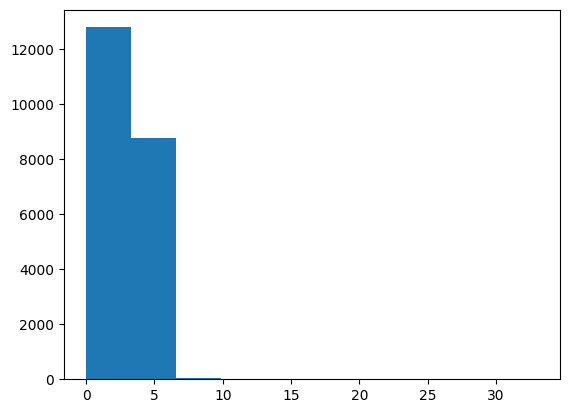

In [176]:
plt.hist(customer_df['No of Bedrooms'])
plt.show()

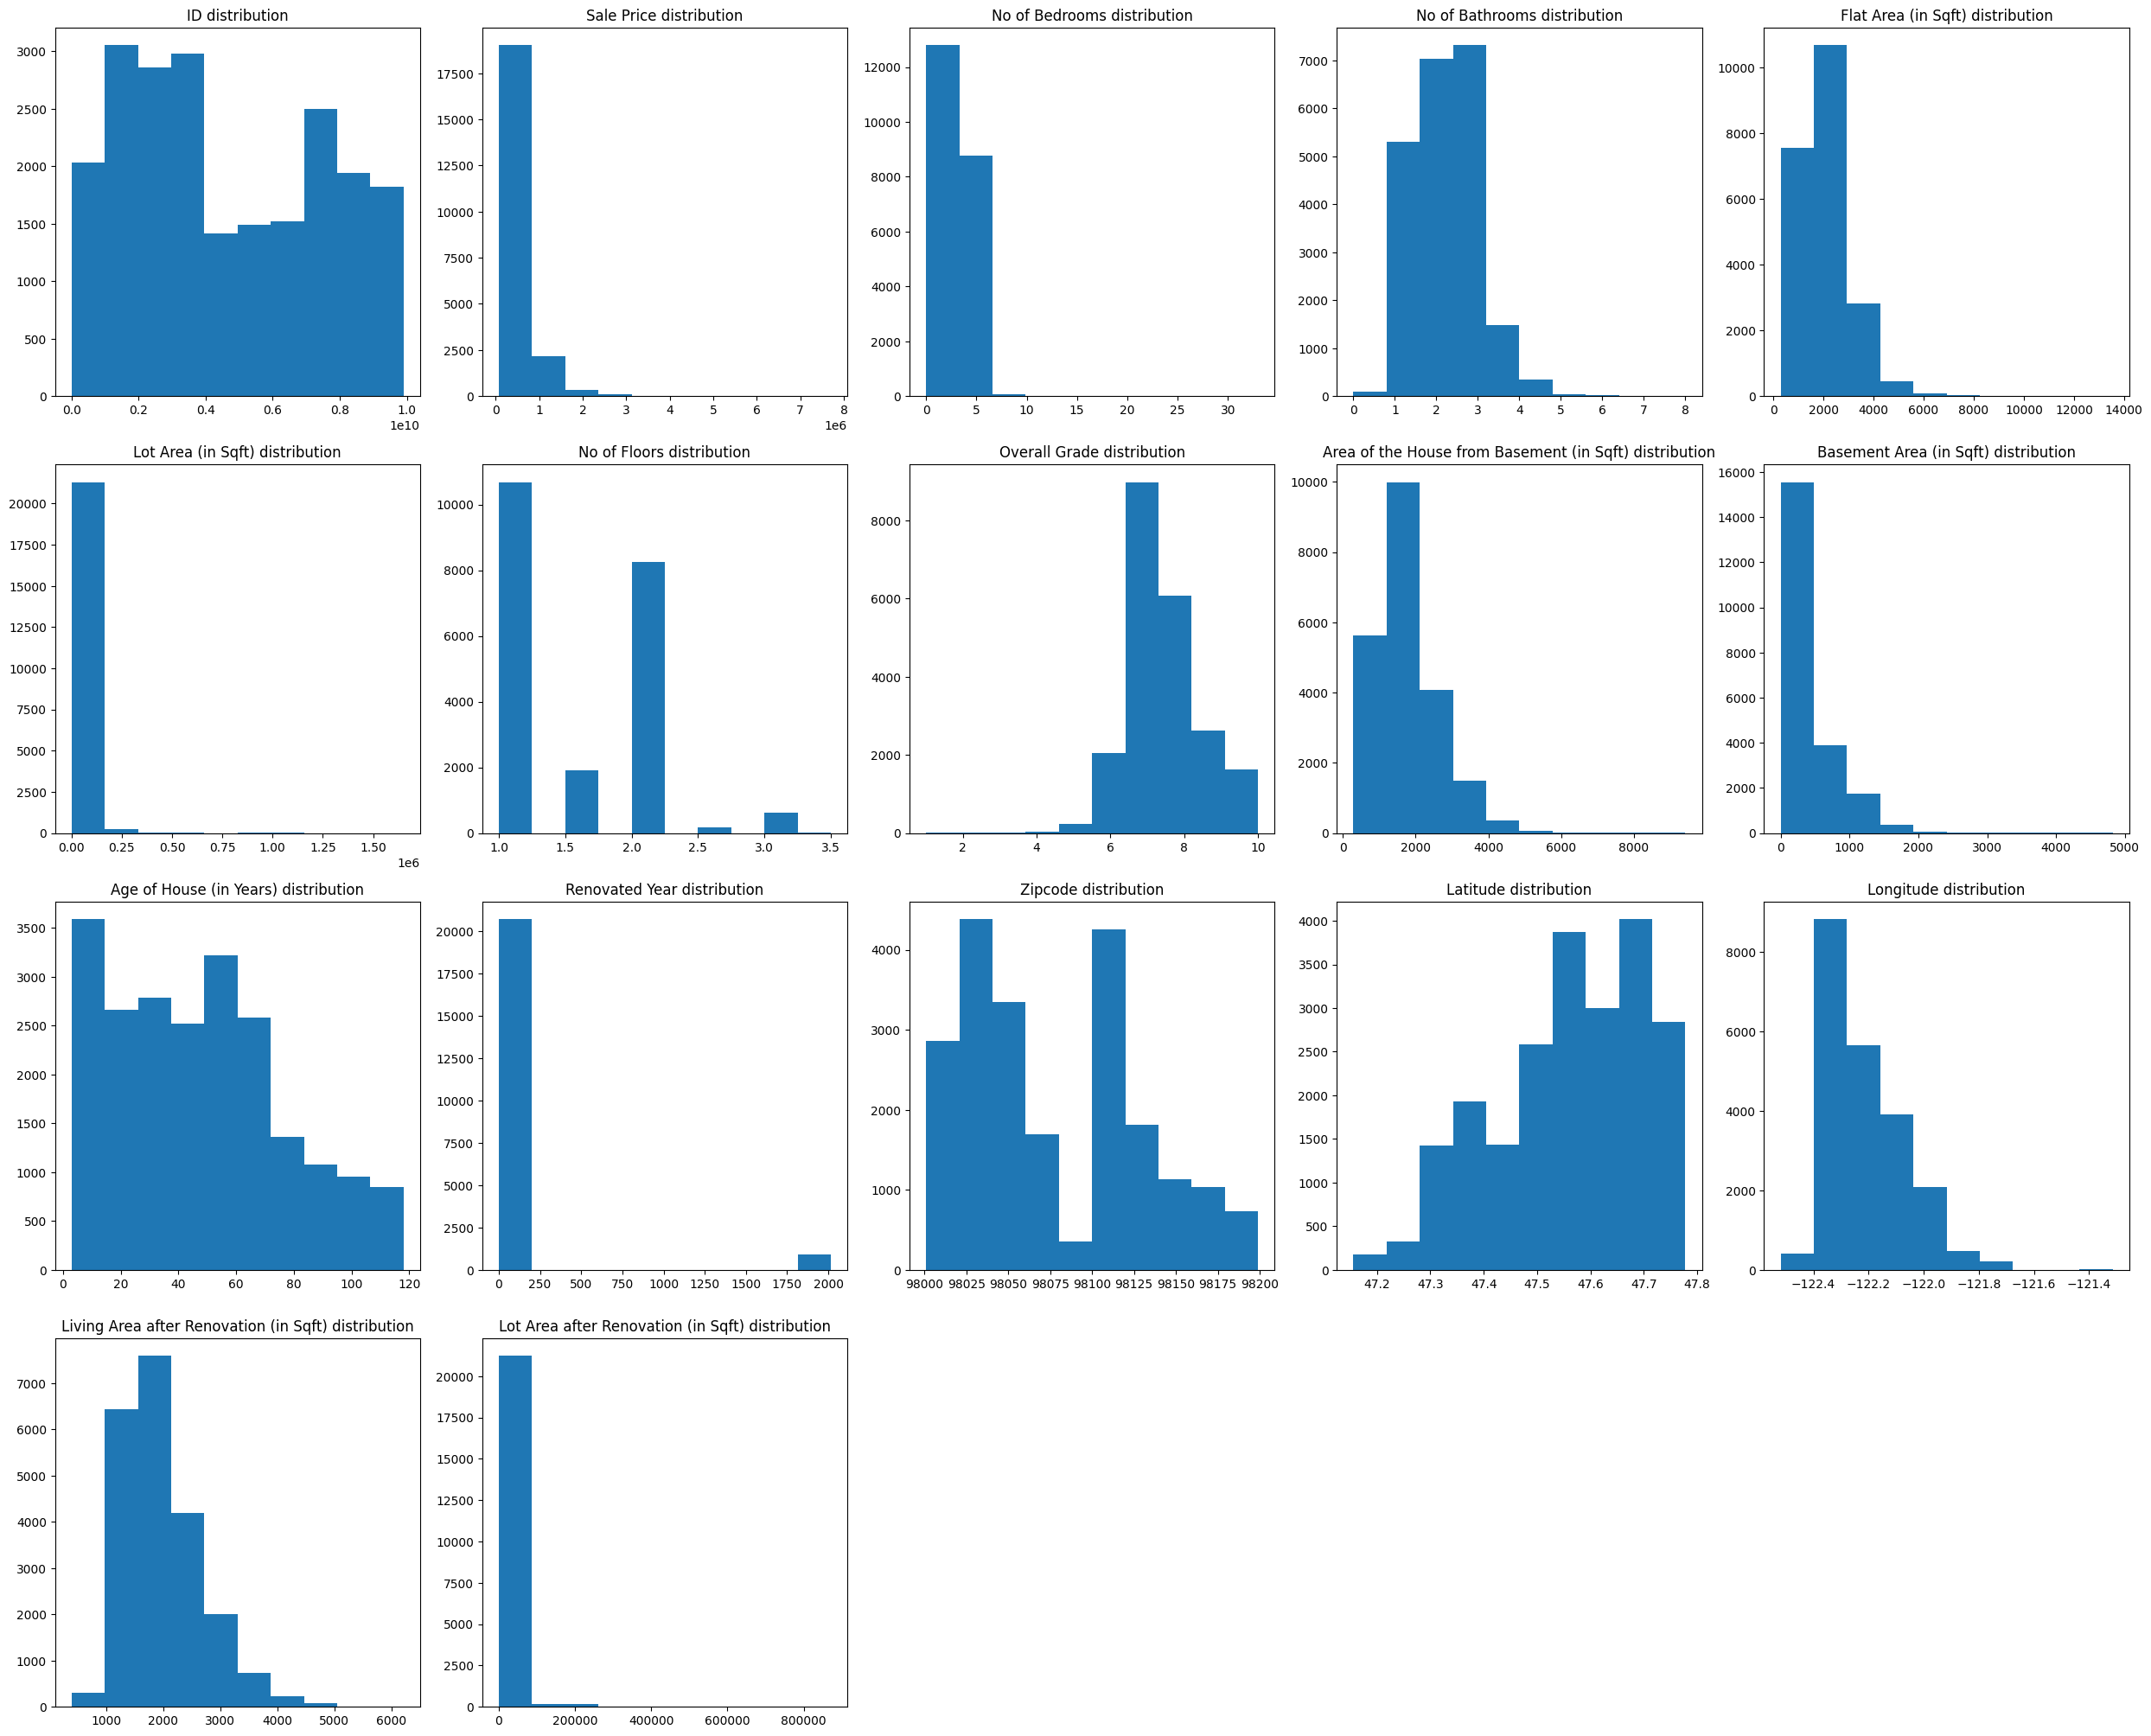

In [177]:
plt.figure(figsize=(25,25))
for i,col in enumerate(num_cols, 1):
  plt.subplot(5,5,i)
  plt.hist(customer_df[col])
  plt.title(col+ " distribution")

plt.tight_layout()
plt.show()

In [178]:
# before the missing value handling
customer_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [ ]:

# Date House was Sold	0

# Waterfront View	0
# No of Times Visited	19489
# Condition of the House	0

# Renovated Year	0


In [180]:
# For Right-Skewed (Positively Skewed) use median imputation

customer_df['Sale Price'].fillna(customer_df['Sale Price'].median() , inplace = True)
customer_df['Lot Area (in Sqft)'].fillna(customer_df['Lot Area (in Sqft)'].median() , inplace = True)
customer_df['Flat Area (in Sqft)'].fillna(customer_df['Flat Area (in Sqft)'].median() , inplace = True)
customer_df['Area of the House from Basement (in Sqft)'].fillna(customer_df['Area of the House from Basement (in Sqft)'].median() , inplace = True)
customer_df['Basement Area (in Sqft)'].fillna(customer_df['Basement Area (in Sqft)'].median() , inplace = True)
customer_df['Living Area after Renovation (in Sqft)'].fillna(customer_df['Living Area after Renovation (in Sqft)'].median() , inplace = True)
customer_df['Lot Area after Renovation (in Sqft)'].fillna(customer_df['Lot Area after Renovation (in Sqft)'].median() , inplace = True)

customer_df['Age of House (in Years)'].fillna(customer_df['Age of House (in Years)'].median() , inplace = True)



/tmp/ipykernel_1679/2493029012.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['Sale Price'].fillna(customer_df['Sale Price'].median() , inplace = True)
/tmp/ipykernel_1679/2493029012.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[co

In [181]:
# For Approximately Symmetric / Slightly Skewed use mean imputation

customer_df['Overall Grade'].fillna(customer_df['Overall Grade'].mean(), inplace=True)
customer_df['Latitude'].fillna(customer_df['Latitude'].mean(), inplace=True)
customer_df['Longitude'].fillna(customer_df['Longitude'].mean(), inplace=True)

/tmp/ipykernel_1679/1303105557.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['Overall Grade'].fillna(customer_df['Overall Grade'].mean(), inplace=True)
/tmp/ipykernel_1679/1303105557.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

In [183]:
# For  Discrete / Slightly Skewed ( perfectly symmetric due to categorical nature)

customer_df['No of Bedrooms'].fillna(customer_df['No of Bedrooms'].median() , inplace = True)
customer_df['No of Bathrooms'].fillna(customer_df['No of Bathrooms'].median() , inplace = True)
customer_df['No of Floors'].fillna(customer_df['No of Floors'].median() , inplace = True)

/tmp/ipykernel_1679/3778357896.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df['No of Bedrooms'].fillna(customer_df['No of Bedrooms'].median() , inplace = True)
/tmp/ipykernel_1679/3778357896.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doin

In [184]:
# For Not Relevant / Categorical-like Features such as ID used drop method

customer_df.drop('ID', axis=1, inplace=True)

In [191]:
# For Not Relevant / Categorical-like Features such as Zipcode use mode imputation

# customer_df['Zipcode'].fillna(customer_df['Zipcode'].mode()[0], inplace=True)
customer_df['Zipcode'] = customer_df['Zipcode'].fillna('Unknown')

In [187]:
# For Not Relevant / Categorical-like Features such as Renovated Year not treat it like a numerical column
customer_df['Renovated Year'] = customer_df['Renovated Year'].fillna(0)

In [189]:
# For Not Relevant / Categorical-like Features such as age_of_house use medium imputation

customer_df['Age of House (in Years)'] = customer_df['Age of House (in Years)'].fillna(customer_df['Age of House (in Years)'].median())

In [192]:
# after the missing value handling
customer_df.isna().sum()

,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19489
Condition of the House,0


# 5) Scaling Numerical Variables

In [193]:
customer_df.head(2)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639


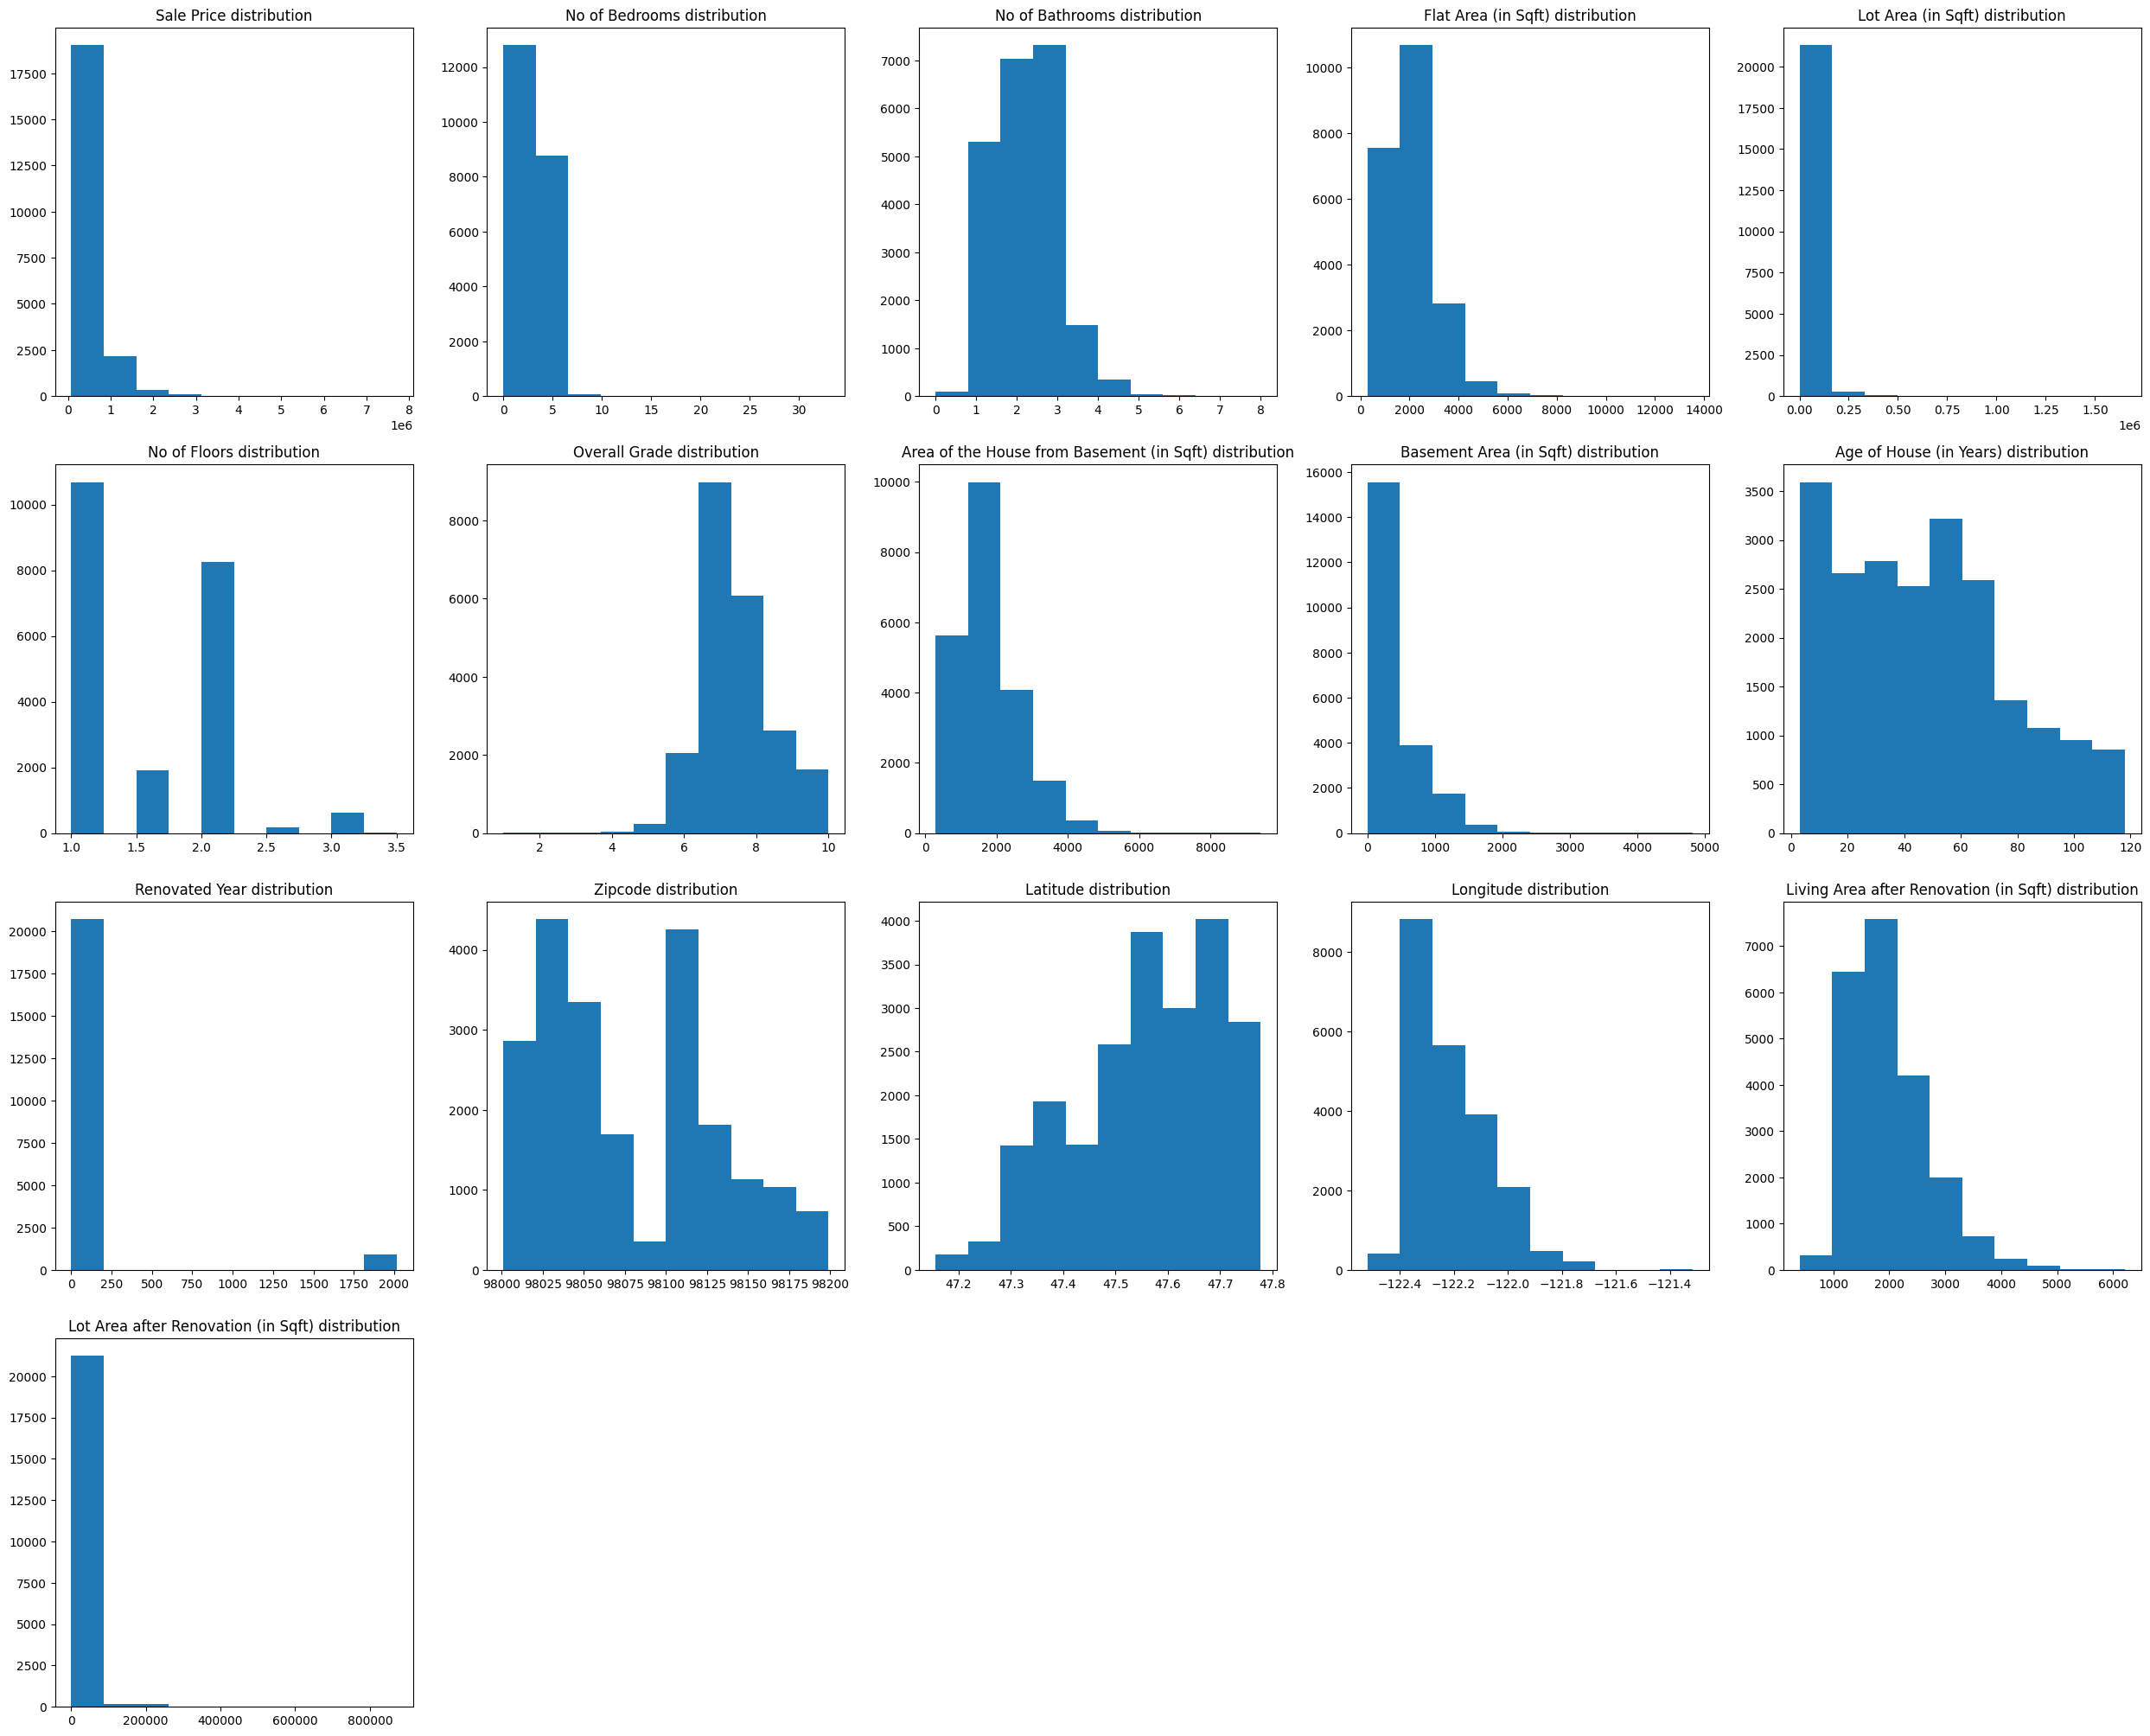

In [195]:
num_cols_updated = customer_df.select_dtypes(include=['number']).columns

plt.figure(figsize=(25,25))
for i,col in enumerate(num_cols_updated, 1):
  plt.subplot(5,5,i)
  plt.hist(customer_df[col])
  plt.title(col+ " distribution")

plt.tight_layout()
plt.show()

In [204]:
# before scaling
customer_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,1.841040e-17,3.370842,2.114757,0.135084,0.008835,1.494309,7.623467,1788.312497,0.060479,0.382564,84.402258,98077.938926,47.560048,-122.213892,0.273194,0.013919
std,1.000023e+00,0.930062,0.770069,0.069306,0.025090,0.539989,1.105439,827.929506,0.091821,0.255421,401.679240,53.504458,0.138562,0.140827,0.117947,0.031364
min,-1.266323e+00,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,0.000000,0.000000,98001.000000,47.155900,-122.519000,0.000000,0.000000
25%,-5.939366e-01,3.000000,1.750000,0.086038,0.002738,1.000000,7.000000,1190.000000,0.000000,0.156522,0.000000,98033.000000,47.471000,-122.328000,0.187747,0.005111
50%,-2.454937e-01,3.000000,2.250000,0.122264,0.004299,1.500000,7.000000,1560.000000,0.000000,0.347826,0.000000,98065.000000,47.571800,-122.230000,0.247978,0.008005
75%,2.853373e-01,4.000000,2.500000,0.170566,0.006157,2.000000,8.000000,2210.000000,0.116183,0.556522,0.000000,98118.000000,47.678000,-122.125000,0.337463,0.010835
max,1.949053e+01,33.000000,8.000000,1.000000,1.000000,3.500000,10.000000,9410.000000,1.000000,1.000000,2015.000000,98199.000000,47.777600,-121.315000,1.000000,1.000000


In [203]:
# before scaling
customer_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,1.841040e-17,3.370842,2.114757,0.135084,0.008835,1.494309,7.623467,1788.312497,0.060479,0.382564,84.402258,98077.938926,47.560048,-122.213892,0.273194,0.013919
std,1.000023e+00,0.930062,0.770069,0.069306,0.025090,0.539989,1.105439,827.929506,0.091821,0.255421,401.679240,53.504458,0.138562,0.140827,0.117947,0.031364
min,-1.266323e+00,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,0.000000,0.000000,98001.000000,47.155900,-122.519000,0.000000,0.000000
25%,-5.939366e-01,3.000000,1.750000,0.086038,0.002738,1.000000,7.000000,1190.000000,0.000000,0.156522,0.000000,98033.000000,47.471000,-122.328000,0.187747,0.005111
50%,-2.454937e-01,3.000000,2.250000,0.122264,0.004299,1.500000,7.000000,1560.000000,0.000000,0.347826,0.000000,98065.000000,47.571800,-122.230000,0.247978,0.008005
75%,2.853373e-01,4.000000,2.500000,0.170566,0.006157,2.000000,8.000000,2210.000000,0.116183,0.556522,0.000000,98118.000000,47.678000,-122.125000,0.337463,0.010835
max,1.949053e+01,33.000000,8.000000,1.000000,1.000000,3.500000,10.000000,9410.000000,1.000000,1.000000,2015.000000,98199.000000,47.777600,-121.315000,1.000000,1.000000


In [206]:
min_max_scalar = MinMaxScaler()

customer_df[['No of Bedrooms','No of Bathrooms','Flat Area (in Sqft)','Lot Area (in Sqft)','No of Floors','Overall Grade','Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)', 'Age of House (in Years)' ,'Renovated Year','Zipcode','Latitude','Longitude']]

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude
0,3,1.00,0.067170,0.003108,1.0,7,1180.0,0.000000,0.161934,0.005742,0.521739,0,98178.0,47.5112,-122.257
1,3,2.25,0.172075,0.004072,2.0,7,2170.0,0.082988,0.222165,0.008027,0.556522,1991,98125.0,47.7210,-122.319
2,2,1.00,0.036226,0.005743,1.0,6,770.0,0.000000,0.399415,0.008513,0.713043,0,98028.0,47.7379,-122.233
3,4,3.00,0.126038,0.002714,1.0,7,1050.0,0.188797,0.165376,0.004996,0.434783,0,98136.0,47.5208,-122.393
4,3,2.00,0.104906,0.004579,1.0,8,1680.0,0.000000,0.241094,0.007871,0.243478,0,98074.0,47.6168,-122.045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,0.093585,0.000370,3.0,8,1530.0,0.000000,0.194631,0.000986,0.052174,0,98103.0,47.6993,-122.346
21609,4,2.50,0.152453,0.003206,2.0,8,2310.0,0.000000,0.246257,0.007523,0.008696,0,98146.0,47.5107,-122.362
21610,2,0.75,0.055094,0.000503,2.0,7,1020.0,0.000000,0.106866,0.001558,0.052174,0,98144.0,47.5944,-122.299
21611,3,2.50,0.098868,0.001132,2.0,8,1600.0,0.000000,0.173980,0.000731,0.095652,0,98027.0,47.5345,-122.069


In [207]:
# min_max_scalar = MinMaxScaler()

# customer_df[['No of Bedrooms','','Flat Area (in Sqft)','Lot Area (in Sqft)', 'Basement Area (in Sqft)', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)', 'Age of House (in Years)' ,'Basement Area (in Sqft)']] = min_max_scalar.fit_transform(customer_df[['Flat Area (in Sqft)','Lot Area (in Sqft)', 'Basement Area (in Sqft)', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)', 'Age of House (in Years)' ,'Basement Area (in Sqft)']])

In [208]:
standard_scaler = StandardScaler()
customer_df['Sale Price'] = standard_scaler.fit_transform(customer_df[['Sale Price']])

In [238]:
# after scaling
customer_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),...,Lot Area after Renovation (in Sqft),No of Times Visited_Four,No of Times Visited_Once,No of Times Visited_Thrice,No of Times Visited_Twice,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
count,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,1.315028e-17,3.370842,2.114757,0.135084,0.008835,1.494309,7.623467,1788.312497,0.060479,0.382564,...,0.013919,0.014760,0.015361,0.023597,0.044557,0.001388,0.078703,0.649193,0.262759,0.007958
std,1.000023e+00,0.930062,0.770069,0.069306,0.025090,0.539989,1.105439,827.929506,0.091821,0.255421,...,0.031364,0.120592,0.122987,0.151793,0.206333,0.037232,0.269280,0.477234,0.440143,0.088855
min,-1.266323e+00,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-5.939366e-01,3.000000,1.750000,0.086038,0.002738,1.000000,7.000000,1190.000000,0.000000,0.156522,...,0.005111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.454937e-01,3.000000,2.250000,0.122264,0.004299,1.500000,7.000000,1560.000000,0.000000,0.347826,...,0.008005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,2.853373e-01,4.000000,2.500000,0.170566,0.006157,2.000000,8.000000,2210.000000,0.116183,0.556522,...,0.010835,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.949053e+01,33.000000,8.000000,1.000000,1.000000,3.500000,10.000000,9410.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 6) Encoding Categorical Variables

In [251]:
# before encoding

customer_df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [252]:
customer_df['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

In [253]:
pd.get_dummies(customer_df, columns=['Condition of the House'])

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,98178.0,47.5112,-122.257,1340.0,5650,False,False,True,False,False
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,98125.0,47.7210,-122.319,1690.0,7639,False,False,True,False,False
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,98028.0,47.7379,-122.233,2720.0,8062,False,False,True,False,False
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,98136.0,47.5208,-122.393,1360.0,5000,False,True,False,False,False
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,98074.0,47.6168,-122.045,1800.0,7503,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,98103.0,47.6993,-122.346,1530.0,1509,False,False,True,False,False
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,98146.0,47.5107,-122.362,1830.0,7200,False,False,True,False,False
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,98144.0,47.5944,-122.299,1020.0,2007,False,False,True,False,False
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,98027.0,47.5345,-122.069,1410.0,1287,False,False,True,False,False


In [254]:
customer_df = pd.get_dummies(customer_df, columns=['Condition of the House'],dtype =int)

In [ ]:
# after encoding

customer_df.head(2)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),...,Lot Area after Renovation (in Sqft),No of Times Visited_Four,No of Times Visited_Once,No of Times Visited_Thrice,No of Times Visited_Twice,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,14 October 2017,-0.866430,3,1.00,0.067170,0.003108,1.0,No,7,1180.0,...,0.005742,0,0,0,0,0,0,1,0,0
1,14 December 2017,-0.005939,3,2.25,0.172075,0.004072,2.0,No,7,2170.0,...,0.008027,0,0,0,0,0,0,1,0,0


# 7) Outlier Removal

In [259]:
customer_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [260]:
customer_df['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

In [261]:

customer_df['No of Times Visited'].unique()

array([nan, 'Thrice', 'Four', 'Twice', 'Once'], dtype=object)